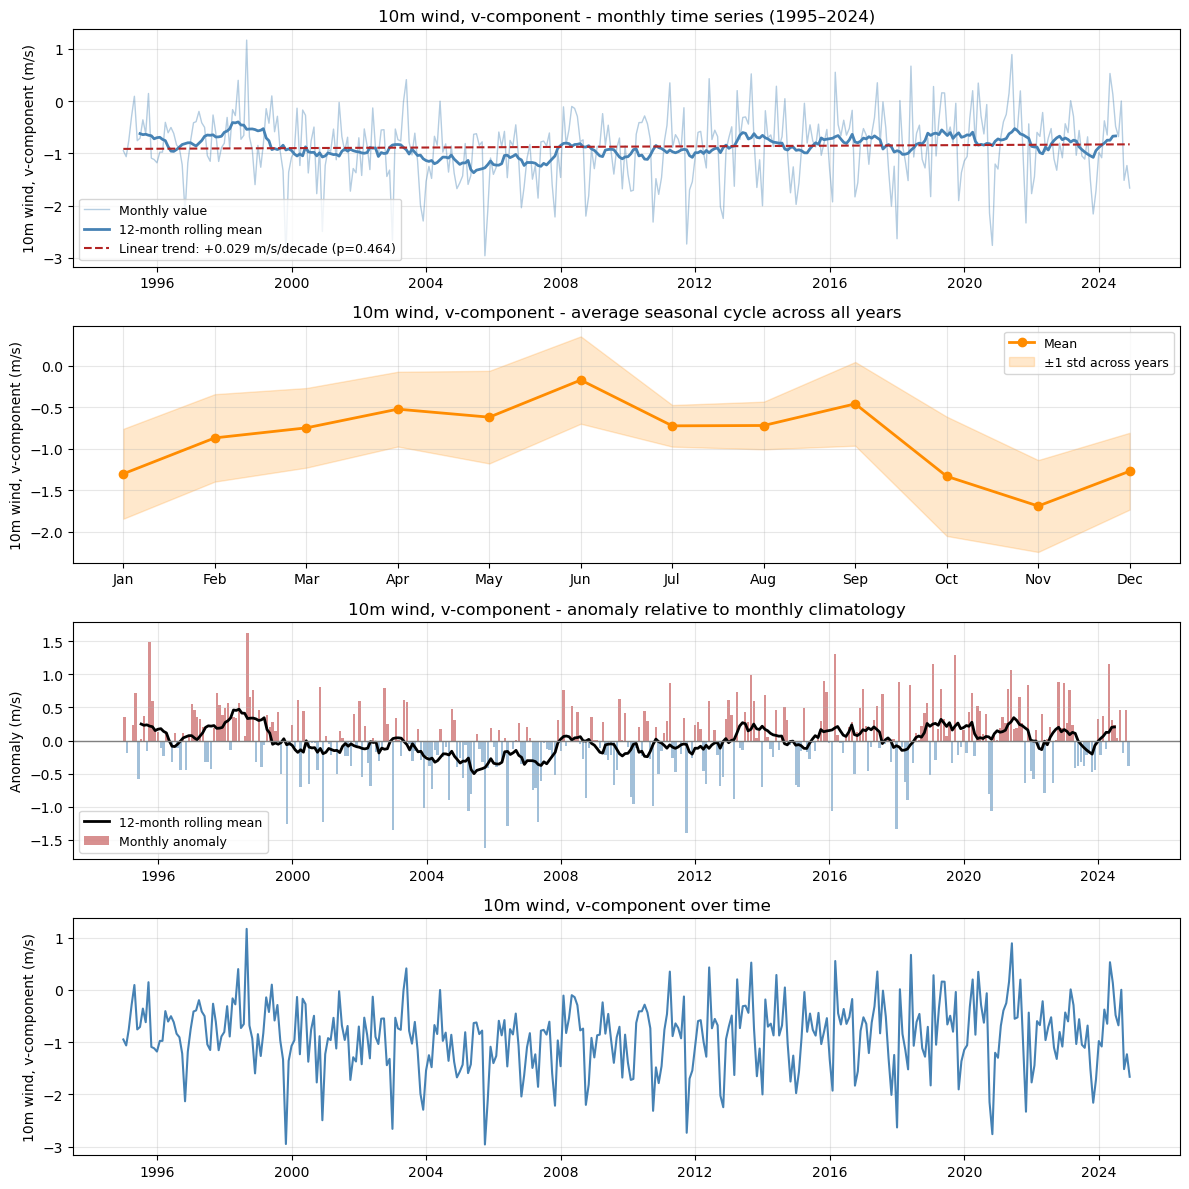

Variable: 10m wind, v-component (wind_v_c1)
Period covered: 1995-01 to 2024-12
Missing months: 0
Overall mean: -0.871 m/s
Linear trend: +0.0291 m/s per decade (R²=0.002, p=0.4637)
Warmest/highest month on record: 1998-09 (1.167)
Coolest/lowest month on record: 2005-10 (-2.959)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

CSV_PATH = "ERA5_HYCOM_monthly_sisal.csv"
VARIABLE = "wind_v_c1"  # Change this to the desired variable

VARIABLE_INFO = {
    "salinity_psu": {"label": "Sea surface salinity", "unit": "PSU", "convert": lambda x: x},
    "sea_surface_elevation_m": {"label": "Sea surface elevation anomaly", "unit": "m", "convert": lambda x: x},
    "sst_c": {"label": "Sea surface temperature", "unit": "\u00b0C", "convert": lambda x: x},
    "surface_pressure_c1": {"label": "Surface pressure", "unit": "hPa", "convert": lambda x: x / 100},
    "temperature_2m_c1": {"label": "2m air temperature", "unit": "\u00b0C", "convert": lambda x: x - 273.15},
    "total_evaporation_c1": {"label": "Total evaporation", "unit": "mm/month", "convert": lambda x: x * 1000},
    "total_precipitation_c1": {"label": "Total precipitation", "unit": "mm/month", "convert": lambda x: x * 1000},
    "wind_u_c1": {"label": "10m wind, u-component", "unit": "m/s", "convert": lambda x: x},
    "wind_v_c1": {"label": "10m wind, v-component", "unit": "m/s", "convert": lambda x: x},
}

df = pd.read_csv(CSV_PATH)
df["date"] = pd.to_datetime(df["date"], format="%Y-%m")
df = df.sort_values("date").reset_index(drop=True)

info = VARIABLE_INFO[VARIABLE]
df["value"] = info["convert"](df[VARIABLE])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

climatology = df.groupby("month")["value"].agg(["mean", "std"])
df = df.merge(climatology["mean"].rename("clim_mean"), on="month")
df["anomaly"] = df["value"] - df["clim_mean"]
df["rolling_12m"] = df["value"].rolling(12, center=True).mean()
df["anomaly_rolling_12m"] = df["anomaly"].rolling(12, center=True).mean()

valid = df.dropna(subset=["value"])
years_since_start = (valid["date"] - valid["date"].iloc[0]).dt.days / 365.25
slope, intercept, r_value, p_value, std_err = stats.linregress(years_since_start, valid["value"])
trend_per_decade = slope * 10

fig, axes = plt.subplots(4, 1, figsize=(12, 12))

ax = axes[0]
ax.plot(df["date"], df["value"], color="steelblue", alpha=0.4, linewidth=1, label="Monthly value")
ax.plot(df["date"], df["rolling_12m"], color="steelblue", linewidth=2, label="12-month rolling mean")
trend_line = intercept + slope * years_since_start
ax.plot(valid["date"], trend_line, color="firebrick", linestyle="--", linewidth=1.5,
        label=f"Linear trend: {trend_per_decade:+.3f} {info['unit']}/decade (p={p_value:.3f})")
ax.set_title(f"{info['label']} - monthly time series (1995\u20132024)")
ax.set_ylabel(f"{info['label']} ({info['unit']})")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
months = climatology.index
ax.plot(months, climatology["mean"], color="darkorange", marker="o", linewidth=2, label="Mean")
ax.fill_between(months, climatology["mean"] - climatology["std"], climatology["mean"] + climatology["std"],
                 color="darkorange", alpha=0.2, label="\u00b11 std across years")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_title(f"{info['label']} - average seasonal cycle across all years")
ax.set_ylabel(f"{info['label']} ({info['unit']})")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
colors = np.where(df["anomaly"] >= 0, "firebrick", "steelblue")
ax.bar(df["date"], df["anomaly"], width=25, color=colors, alpha=0.5, label="Monthly anomaly")
ax.plot(df["date"], df["anomaly_rolling_12m"], color="black", linewidth=2, label="12-month rolling mean")
ax.axhline(0, color="grey", linewidth=1)
ax.set_title(f"{info['label']} - anomaly relative to monthly climatology")
ax.set_ylabel(f"Anomaly ({info['unit']})")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.3)

ax = axes[3]
ax.plot(df["date"], df["value"], color="steelblue", linewidth=1.5)
ax.set_title(f"{info['label']} over time")
ax.set_ylabel(f"{info['label']} ({info['unit']})")
ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

print(f"Variable: {info['label']} ({VARIABLE})")
print(f"Period covered: {df['date'].min().strftime('%Y-%m')} to {df['date'].max().strftime('%Y-%m')}")
print(f"Missing months: {df['value'].isna().sum()}")
print(f"Overall mean: {valid['value'].mean():.3f} {info['unit']}")
print(f"Linear trend: {trend_per_decade:+.4f} {info['unit']} per decade (R\u00b2={r_value**2:.3f}, p={p_value:.4f})")
print(f"Warmest/highest month on record: {valid.loc[valid['value'].idxmax(), 'date'].strftime('%Y-%m')} ({valid['value'].max():.3f})")
print(f"Coolest/lowest month on record: {valid.loc[valid['value'].idxmin(), 'date'].strftime('%Y-%m')} ({valid['value'].min():.3f})")